## Step 1. Imports and configuration

In [1]:
from pathlib import Path
from typing import Final

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Display and plotting configuration
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")
sns.set_theme(style="whitegrid", context="notebook", palette="deep")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 110

# Paths and constants. EDA runs on the TRAIN split only, to avoid leakage.
TRAIN_PATH: Final[Path] = Path("../src/ml_model/data/processed/loans_train.parquet")
TARGET: Final[str] = "is_default"

## Step 2. Load the training split and inspect its structure

In [2]:
if not TRAIN_PATH.exists():
    raise FileNotFoundError(
        f"{TRAIN_PATH.resolve()} not found. Run this notebook from the notebooks/ folder."
    )

df: pd.DataFrame = pd.read_parquet(TRAIN_PATH)

print(f"Loaded training split: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Target column '{TARGET}' present: {TARGET in df.columns}\n")

stale_cols = sorted({"int_rate", "installment"} & set(df.columns))
print(f"\nLeakage-prone columns still in the file: {stale_cols or 'none'}")

Loaded training split: 1,076,280 rows x 14 columns
Target column 'is_default' present: True


Leakage-prone columns still in the file: none


## Step 3. Schema check (replaces `.info()`)

In [3]:
schema: pd.DataFrame = pd.DataFrame(
    {
        "dtype": df.dtypes.astype(str),
        "non_null": df.count(),
        "n_unique": df.nunique(),
        "memory_mb": df.memory_usage(deep=True, index=False) / 1024**2,
    }
)

print(f"Total memory: {schema['memory_mb'].sum():,.1f} MB")
schema

Total memory: 150.6 MB


,dtype,non_null,n_unique,memory_mb
loan_amnt,float64,1076280,1546,8.211
emp_length,float64,1013461,11,8.211
annual_inc,float64,1076280,55295,8.211
dti,float64,1075986,6699,8.211
fico_range_low,float64,1076280,40,8.211
open_acc,float64,1076280,83,8.211
pub_rec,float64,1076280,34,8.211
revol_util,float64,1075579,1331,8.211
mort_acc,float64,1038334,38,8.211
term,str,1076280,2,17.449


### Conclusions: data loading and schema check

- **Scope:** the training split has 1,076,280 loans and 14 columns (13 predictors + the target `is_default`). It is the stratified 80% part of the 1,345,350 resolved loans (Fully Paid / Charged Off / Default). The test split has not been loaded, so the EDA is leakage-free.
- **Leakage guard:** `int_rate` and `installment` are absent, so the file matches the final feature whitelist.
- **Types:** 9 numeric predictors (`float64`), 4 categorical predictors (`term`, `home_ownership`, `verification_status`, `purpose`; stored as `str`) and a binary target (`int8`).
- **Missing values:** only 4 of 14 columns have gaps: `emp_length` (62,819; 5.84%), `mort_acc` (37,946; 3.53%), `revol_util` (701; 0.07%) and `dti` (294; 0.03%). The other 10 columns are complete. Whether the gaps overlap and whether they relate to default is examined in the missingness step.
- **Cardinality:** categorical features have only 2-14 levels, so one-hot encoding is feasible. `emp_length` (11 values, 0-10) and `fico_range_low` (40 values) behave like ordinal or banded variables. `open_acc`, `pub_rec` and `mort_acc` are count-like (34-83 values). `loan_amnt`, `annual_inc`, `dti` and `revol_util` are close to continuous.
- **Memory:** 150.6 MB in total, so no optimization is needed.

## Step 4. Class counts, default rate and imbalance ratio

In [4]:
target_counts: pd.Series = df[TARGET].value_counts().sort_index()

target_profile: pd.DataFrame = pd.DataFrame(
    {
        "count": target_counts,
        "share_pct": target_counts / len(df) * 100,
    }
)
target_profile.index = ["0 (Fully Paid)", "1 (Default)"]

default_rate: float = df[TARGET].mean()
imbalance_ratio: float = target_counts.loc[0] / target_counts.loc[1]

print(f"Training rows:   {len(df):,}")
print(f"Default rate:    {default_rate:.4%}")
print(f"Imbalance ratio: {imbalance_ratio:.2f} : 1 (non-default : default)")
print(f"Missing target:  {df[TARGET].isna().sum()}\n")
target_profile

Training rows:   1,076,280
Default rate:    19.9650%
Imbalance ratio: 4.01 : 1 (non-default : default)
Missing target:  0



,count,share_pct
0 (Fully Paid),861401,80.035
1 (Default),214879,19.965


## Step 5. Bar chart of the class distribution

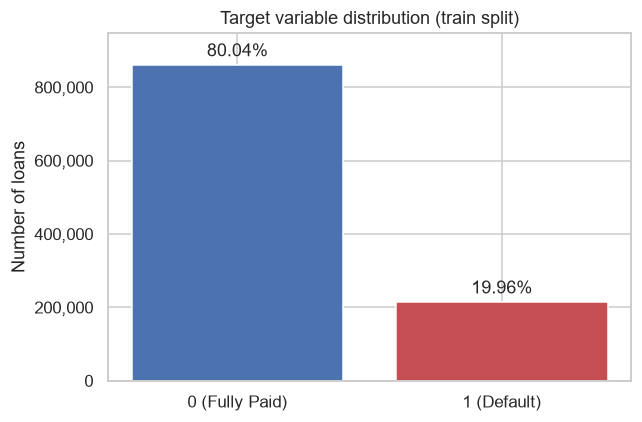

In [5]:
from matplotlib.ticker import StrMethodFormatter

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(
    target_profile.index.to_list(),
    target_profile["count"].to_numpy(),
    color=["#4C72B0", "#C44E52"],
)
ax.bar_label(
    bars,
    labels=[f"{share:.2f}%" for share in target_profile["share_pct"]],
    padding=3,
)

ax.set_title("Target variable distribution (train split)")
ax.set_ylabel("Number of loans")
ax.set_ylim(0, target_profile["count"].max() * 1.1)
ax.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
plt.tight_layout()
plt.show()

### Conclusions: target variable profile

- **Class balance:** 861,401 loans were repaid in full (80.04%) and 214,879 defaulted (19.96%), an imbalance of 4.01 : 1. The target has no missing values.
- **Split check:** the default rate in the training split (19.965%) equals the rate in the full filtered dataset (19.965%), so the stratified split preserved the class balance.
- **Severity:** the imbalance is moderate, not extreme. With over 214 thousand defaults, the minority class is large enough that resampling is typically unnecessary.
- **Consequence for modelling:** a trivial "always non-default" model already reaches 80.04% accuracy, so accuracy is not a meaningful metric here. Evaluation will use ROC AUC, PR AUC, KS and precision/recall at a chosen threshold. Imbalance will be handled with class weights and threshold tuning, keeping stratified splits and stratified cross-validation.
- **Caveat on the target definition:** the target is built only from resolved loans (Fully Paid, Charged Off, Default). About 40% of the raw records, mostly loans still "Current", were excluded. So 19.96% is the default rate among resolved loans, not the portfolio-wide rate.

## Step 6. Feature lists and descriptive statistics

In [6]:
NUMERIC_FEATURES: Final[list[str]] = [
    "loan_amnt",
    "annual_inc",
    "dti",
    "emp_length",
    "fico_range_low",
    "open_acc",
    "pub_rec",
    "revol_util",
    "mort_acc",
]
CATEGORICAL_FEATURES: Final[list[str]] = [
    "term",
    "home_ownership",
    "verification_status",
    "purpose",
]

numeric_summary: pd.DataFrame = (
    df[NUMERIC_FEATURES]
    .describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])
    .T.drop(columns="count")
)
numeric_summary["skew"] = df[NUMERIC_FEATURES].skew()
numeric_summary["zero_pct"] = (
    df[NUMERIC_FEATURES].eq(0).sum() / df[NUMERIC_FEATURES].count() * 100
)
numeric_summary

,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,skew,zero_pct
loan_amnt,"14,421.580","8,720.808",500.000,"1,500.000","3,200.000","8,000.000","12,000.000","20,000.000","32,950.000","35,000.000","40,000.000",0.783,0.000
annual_inc,"76,246.813","69,164.691",0.000,"18,000.000","28,000.000","45,900.000","65,000.000","90,000.000","155,000.000","250,854.180","9,550,000.000",44.659,0.026
dti,18.286,11.223,-1.000,1.780,4.980,11.800,17.620,24.060,32.980,38.470,999.000,27.665,0.064
emp_length,5.964,3.691,0.000,0.000,0.000,2.000,6.000,10.000,10.000,10.000,10.000,-0.216,8.544
fico_range_low,696.190,31.866,625.000,660.000,660.000,670.000,690.000,710.000,760.000,800.000,845.000,1.285,0.000
open_acc,11.595,5.478,0.000,3.000,5.000,8.000,11.000,14.000,22.000,29.000,90.000,1.302,0.001
pub_rec,0.215,0.598,0.000,0.000,0.000,0.000,0.000,0.000,1.000,2.000,63.000,10.325,83.086
revol_util,51.820,24.529,0.000,1.100,10.400,33.500,52.200,70.800,91.500,98.200,892.300,-0.029,0.519
mort_acc,1.670,2.000,0.000,0.000,0.000,0.000,1.000,3.000,6.000,8.000,51.000,1.639,40.364


## Step 7. Histograms of the 9 numeric features

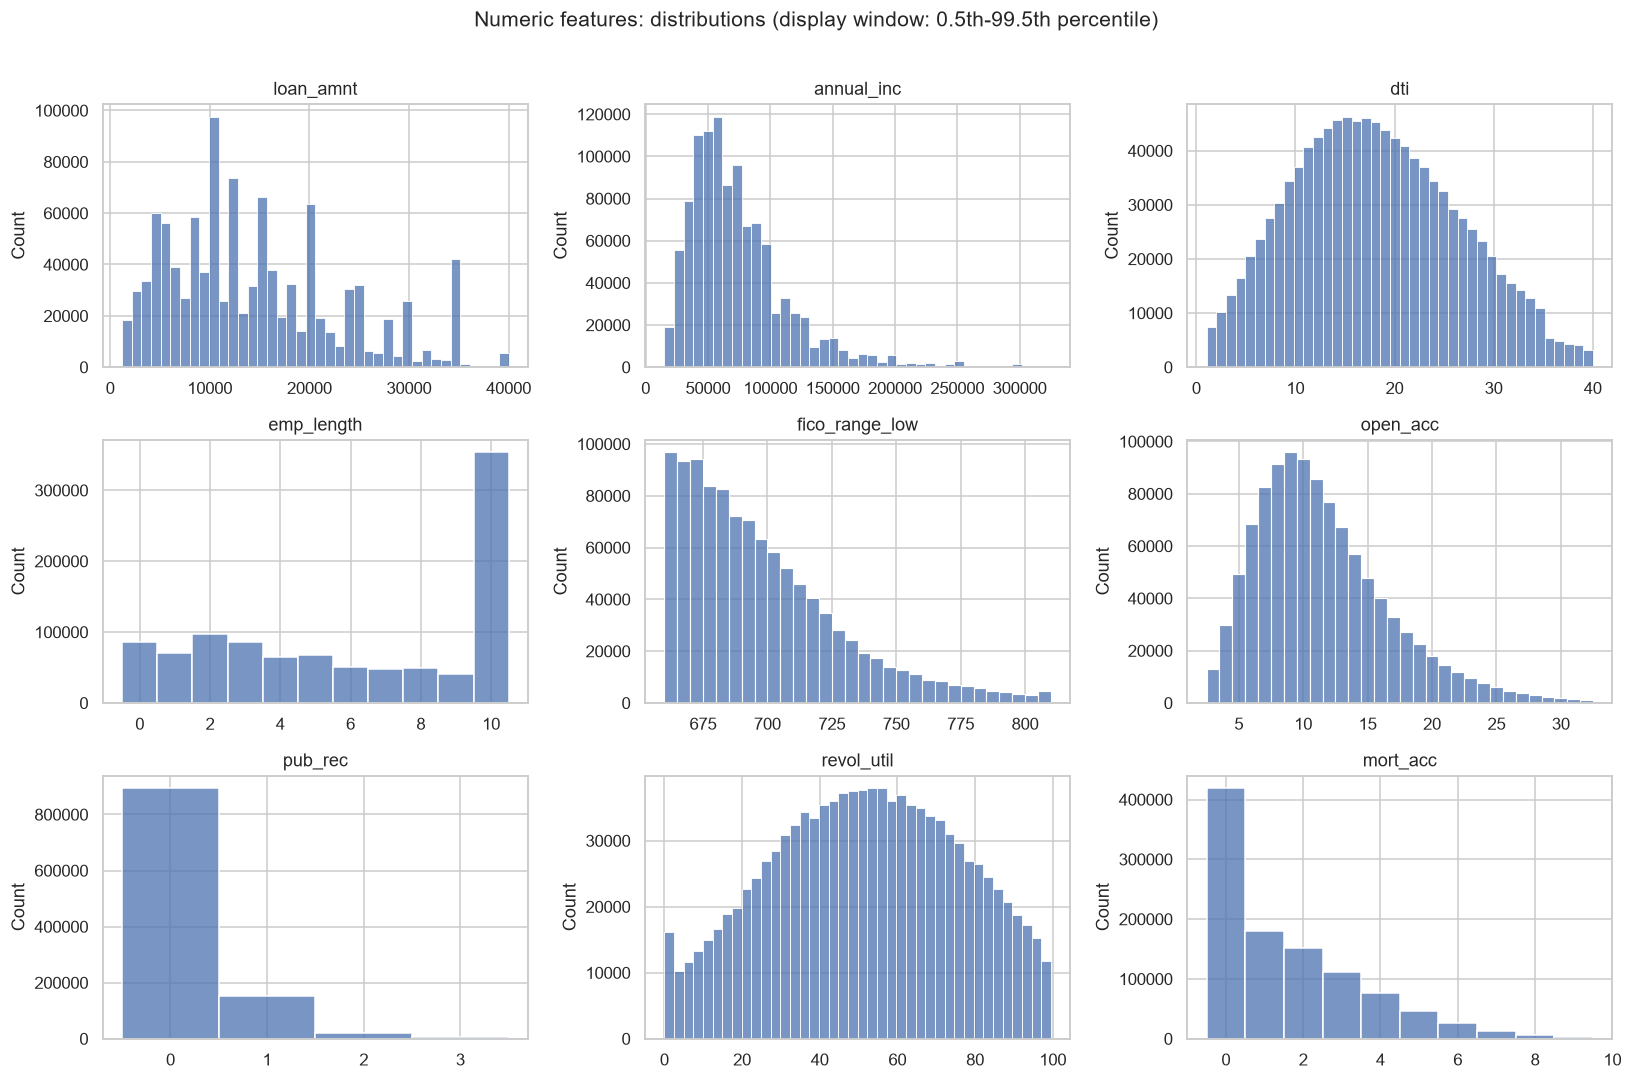

In [7]:
DISCRETE_FEATURES: Final[set[str]] = {"emp_length", "open_acc", "pub_rec", "mort_acc"}

fig, axes = plt.subplots(3, 3, figsize=(15, 10))

for ax, col in zip(axes.ravel(), NUMERIC_FEATURES):
    # Display window only: trims the extreme 0.5% on each side, data is untouched.
    low, high = df[col].quantile([0.005, 0.995])
    values = df.loc[df[col].between(low, high), col]

    if col in DISCRETE_FEATURES:
        sns.histplot(values, discrete=True, ax=ax)
    elif col == "fico_range_low":
        sns.histplot(values, binwidth=5, ax=ax)
    else:
        sns.histplot(values, bins=40, ax=ax)

    ax.set_title(col)
    ax.set_xlabel("")
    ax.set_ylabel("Count")

fig.suptitle(
    "Numeric features: distributions (display window: 0.5th-99.5th percentile)",
    fontsize=14,
)
fig.tight_layout(rect=(0, 0, 1, 0.97))
plt.show()

### Conclusions: numeric feature distributions
* **`loan_amnt`:** bounded between 500 and 40,000 dollars (median 12,000 dollars) with a mild right skew (0.78). It clusters at round amounts (10k, 12k, 15k, 20k, 35k dollars), so it behaves like a quasi-discrete variable. No outlier treatment is needed.
* **`annual_inc` and `dti`:** both have extreme right tails. For `annual_inc` the median is 65,000 dollars and the 99th percentile 250,854 dollars, but the maximum is 9.55 million dollars (skew 44.7), and about 280 loans report zero income. `dti` is bell-shaped in the 1-40 range, yet it spans -1 to 999 (skew 27.7). A negative ratio and the value 999 look like placeholder codes rather than real measurements.
* **`fico_range_low`:** ranges from 625 to 845 and is right-skewed (1.29). Both the 1st and 5th percentiles equal 660, and the histogram starts abruptly there, consistent with a minimum-score approval policy. Only accepted applicants are observed, so the sample is truncated (selection bias; rejected applicants are not modelled).
* **`emp_length`:** a top-coded ordinal variable. About 8.5% of borrowers have under one year, counts decline gently from 0 to 9 years, and the spike at 10 is the "10+ years" category (roughly a third of borrowers with a known value).
* **`open_acc` and `revol_util`:** `open_acc` is a right-skewed count (median 11, maximum 90). `revol_util` is roughly symmetric (skew -0.03, median 52.2%), 99% of loans are at or below 98.2%, and there is a small spike at exactly 0 (0.5% of loans). The maximum of 892.3% is implausible and needs checking.
* **`pub_rec` and `mort_acc`:** zero-inflated counts. 83.1% of borrowers have no public records (maximum 63), and 40.4% of borrowers with a known value have no mortgage accounts. Binary indicators (`> 0`) or capped versions are natural candidates for feature engineering.
* **Implication:** scaling-based models (for example a logistic-regression baseline) would be distorted by the extreme values in `annual_inc`, `dti`, `revol_util` and `pub_rec`, so capping or a log transform is worth testing. Tree-based models such as the planned Random Forest are largely insensitive to them.

## Step 8. IQR outlier audit

In [8]:
IQR_FEATURES: Final[list[str]] = [
    col for col in NUMERIC_FEATURES if col not in {"emp_length", "pub_rec"}
]


def iqr_outlier_summary(
    frame: pd.DataFrame, columns: list[str], k: float
) -> pd.DataFrame:
    """Count values outside the Tukey fences [Q1 - k*IQR, Q3 + k*IQR]."""
    q1: pd.Series = frame[columns].quantile(0.25)
    q3: pd.Series = frame[columns].quantile(0.75)
    iqr: pd.Series = q3 - q1
    lower: pd.Series = q1 - k * iqr
    upper: pd.Series = q3 + k * iqr
    n_below: pd.Series = frame[columns].lt(lower, axis="columns").sum()
    n_above: pd.Series = frame[columns].gt(upper, axis="columns").sum()
    n_outliers: pd.Series = n_below + n_above
    return pd.DataFrame(
        {
            "lower_fence": lower,
            "upper_fence": upper,
            "n_outliers": n_outliers,
            "outlier_pct": n_outliers / frame[columns].count() * 100,
        }
    )


mild: pd.DataFrame = iqr_outlier_summary(df, IQR_FEATURES, k=1.5)
extreme: pd.DataFrame = iqr_outlier_summary(df, IQR_FEATURES, k=3.0)

outlier_report: pd.DataFrame = pd.DataFrame(
    {
        "lower_fence_1.5": mild["lower_fence"],
        "upper_fence_1.5": mild["upper_fence"],
        "outlier_pct_1.5": mild["outlier_pct"],
        "outlier_pct_3.0": extreme["outlier_pct"],
        "n_extreme_3.0": extreme["n_outliers"],
    }
)
outlier_report

,lower_fence_1.5,upper_fence_1.5,outlier_pct_1.5,outlier_pct_3.0,n_extreme_3.0
loan_amnt,"-10,000.000","38,000.000",0.534,0.000,0
annual_inc,"-20,250.000","156,150.000",4.896,1.641,17661
dti,-6.590,42.450,0.405,0.123,1324
fico_range_low,610.000,770.000,3.460,0.062,670
open_acc,-1.000,23.000,3.439,0.482,5188
revol_util,-22.450,126.750,0.005,0.000,5
mort_acc,-4.500,7.500,1.375,0.083,862


## Step 9. Rule-based suspicious values and their default rates

In [9]:
suspicious_rules: Final[dict[str, pd.Series]] = {
    "annual_inc == 0": df["annual_inc"].eq(0),
    "annual_inc > 1,000,000": df["annual_inc"].gt(1_000_000),
    "dti < 0": df["dti"].lt(0),
    "dti > 100": df["dti"].gt(100),
    "revol_util > 100": df["revol_util"].gt(100),
    "pub_rec >= 3": df["pub_rec"].ge(3),
}

baseline_rate: float = df[TARGET].mean() * 100
records: list[dict[str, str | int | float]] = []
for rule, mask in suspicious_rules.items():
    records.append(
        {
            "rule": rule,
            "n_rows": int(mask.sum()),
            "share_pct": mask.mean() * 100,
            "default_rate_pct": df.loc[mask, TARGET].mean() * 100,
        }
    )

print(f"Baseline default rate (all training rows): {baseline_rate:.3f}%\n")
suspicious_report: pd.DataFrame = pd.DataFrame(records).set_index("rule")
suspicious_report

Baseline default rate (all training rows): 19.965%



,n_rows,share_pct,default_rate_pct
rule,,,
annual_inc == 0,282,0.026,18.085
"annual_inc > 1,000,000",239,0.022,11.715
dti < 0,1,0.000,0.000
dti > 100,428,0.040,26.402
revol_util > 100,3737,0.347,26.278
pub_rec >= 3,10103,0.939,22.973


### Conclusions: outliers and suspicious values

- **Outliers are almost purely upper-tail.** The lower Tukey fences are negative for all variables that cannot go below zero, and the lower fence of `fico_range_low` (610) lies below its minimum (625), so nothing is flagged on the low side.
- **Size of the tails.** At 1.5×IQR the most flagged variables are `annual_inc` (4.9%), `fico_range_low` (3.5%) and `open_acc` (3.4%). At the stricter 3×IQR level the share falls to 1.64% for `annual_inc` (17,661 loans), 0.48% for `open_acc`, 0.12% for `dti` and 0.08% for `mort_acc`. `loan_amnt` has none (it is capped at $40,000) and `revol_util` only 5. For skewed variables the 1.5×IQR rule over-flags genuine high values (wealthy or prime borrowers), so the 3×IQR level is the more meaningful screen.
- **Extreme values on the risky side carry signal.** Loans with `revol_util` > 100% (3,737 loans), `dti` > 100 (428) and `pub_rec` >= 3 (10,103) default at 26.3%, 26.4% and 23.0%, against a 19.97% baseline. Under a binomial approximation these gaps are about 10, 3.3 and 7.5 standard errors, so they are not sampling noise. Deleting these rows would remove some of the riskiest borrowers.
- **Very high income lowers risk.** The 239 loans with `annual_inc` above $1 million default at only 11.7% (about -3.2 standard errors from baseline), so they are genuine borrowers rather than data errors.
- **Harmless anomalies.** The 282 zero-income loans default at 18.1%, statistically indistinguishable from the baseline (about -0.8 standard errors), and only one loan has a negative `dti`. Zero income requires safe division if ratio features such as loan-to-income are built.
- **Decision:** no rows are removed. Candidate treatments to test inside the training pipeline: clipping at a high percentile fitted on the training data (for `annual_inc`, `dti`, `revol_util`, `pub_rec`), `log1p` for `annual_inc`, and `RobustScaler` instead of `StandardScaler`.

## Step 10. Level frequencies and default rate per level

In [10]:
def category_profile(frame: pd.DataFrame, col: str, target: str) -> pd.DataFrame:
    """Level counts, shares and default rate for one categorical feature."""
    grouped = frame.groupby(col, observed=True)[target]
    profile = pd.DataFrame(
        {
            "count": grouped.size(),
            "share_pct": grouped.size() / len(frame) * 100,
            "default_rate_pct": grouped.mean() * 100,
        }
    )
    return profile.sort_values("default_rate_pct", ascending=False)


category_report: pd.DataFrame = pd.concat(
    {col: category_profile(df, col, TARGET) for col in CATEGORICAL_FEATURES},
    names=["feature", "level"],
)
category_report["lift"] = category_report["default_rate_pct"] / baseline_rate

print(f"Baseline default rate: {baseline_rate:.3f}%\n")
category_report

Baseline default rate: 19.965%



count  share_pct  default_rate_pct  \
feature             level                                                     
term                60 months           259613     24.121            32.444   
                    36 months           816667     75.879            15.998   
home_ownership      RENT                427804     39.748            23.214   
                    OWN                 115676     10.748            20.664   
                    OTHER                  382      0.035            18.325   
                    MORTGAGE            532418     49.468            17.204   
verification_status Verified            334493     31.079            23.853   
                    Source Verified     417079     38.752            20.965   
                    Not Verified        324708     30.169            14.675   
purpose             small_business       12361      1.148            29.383   
                    renewable_energy       729      0.068            23.731   
                    moving                7580      0.704            23.325   
                    house                 5824      0.541            22.321   
                    medical              12442      1.156            21.789   
                    debt_consolidation  624213     57.997            21.153   
                    other                62302      5.789            20.985   
                    vacation              7240      0.673            19.240   
                    major_purchase       23499      2.183            18.703   
                    home_improvement     70166      6.519            17.674   
                    credit_card         236104     21.937            16.934   
                    educational            269      0.025            16.729   
                    car                  11701      1.087            14.879   
                    wedding               1850      0.172            11.946   

                                        lift  
feature             level                     
term                60 months          1.625  
                    36 months          0.801  
home_ownership      RENT               1.163  
                    OWN                1.035  
                    OTHER              0.918  
                    MORTGAGE           0.862  
verification_status Verified           1.195  
                    Source Verified    1.050  
                    Not Verified       0.735  
purpose             small_business     1.472  
                    renewable_energy   1.189  
                    moving             1.168  
                    house              1.118  
                    medical            1.091  
                    debt_consolidation 1.060  
                    other              1.051  
                    vacation           0.964  
                    major_purchase     0.937  
                    home_improvement   0.885  
                    credit_card        0.848  
                    educational        0.838  
                    car                0.745  
                    wedding            0.598

## Step 11. Default rate by level

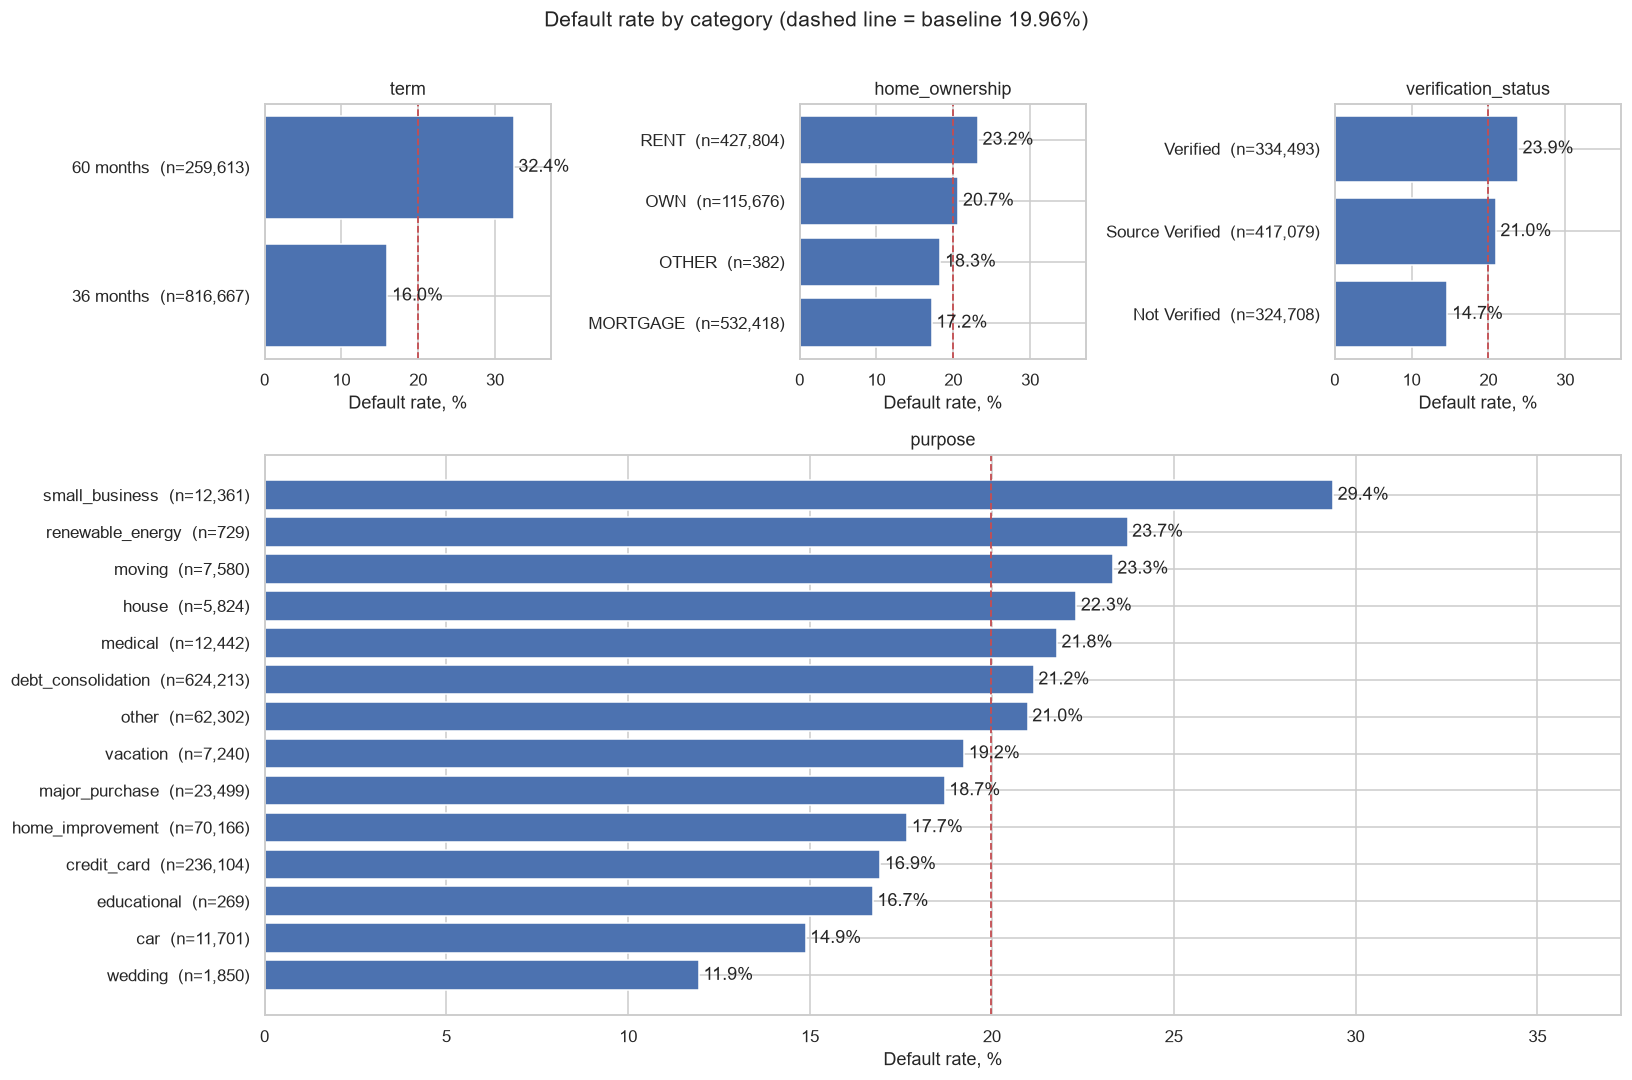

In [11]:
from matplotlib.axes import Axes

fig = plt.figure(figsize=(15, 10))
grid = fig.add_gridspec(2, 3, height_ratios=[1, 2.2])
panels: dict[str, Axes] = {
    "term": fig.add_subplot(grid[0, 0]),
    "home_ownership": fig.add_subplot(grid[0, 1]),
    "verification_status": fig.add_subplot(grid[0, 2]),
    "purpose": fig.add_subplot(grid[1, :]),
}
x_max: float = category_report["default_rate_pct"].max() * 1.15

for col, ax in panels.items():
    profile = category_report.loc[col].sort_values("default_rate_pct")
    tick_labels = [
        f"{level}  (n={n:,})" for level, n in zip(profile.index, profile["count"])
    ]
    bars = ax.barh(tick_labels, profile["default_rate_pct"].to_numpy(), color="#4C72B0")
    ax.bar_label(
        bars, labels=[f"{rate:.1f}%" for rate in profile["default_rate_pct"]], padding=3
    )
    ax.axvline(baseline_rate, color="#C44E52", linestyle="--", linewidth=1.2)
    ax.set_title(col)
    ax.set_xlabel("Default rate, %")
    ax.set_xlim(0, x_max)

fig.suptitle(
    f"Default rate by category (dashed line = baseline {baseline_rate:.2f}%)",
    fontsize=14,
)
fig.tight_layout(rect=(0, 0, 1, 0.97))
plt.show()

### Conclusions: categorical features

- **`term` is the strongest categorical signal.** 60-month loans (24.1% of the data) default at 32.4% versus 16.0% for 36-month loans, a twofold difference (lift 1.63 vs 0.80). Part of the gap may be a sample artefact: recent 60-month loans that are still being repaid are excluded, which biases the resolved sample toward defaults.
- **`home_ownership`:** renters default more often (23.2%) than mortgage holders (17.2%), with owners in between (20.7%). The merged `OTHER` level has only 382 loans (0.04%), and its rate (18.3%) is within sampling noise of the baseline.
- **`verification_status` has a counter-intuitive direction:** Verified loans default at 23.9% and Not Verified loans at 14.7%. Verification is most likely triggered by the lender for riskier or larger applications, so the feature mainly reflects the lender's own screening rather than a protective effect of verified income. It is assumed to be determined before funding, so it is not treated as leakage.
- **`purpose`:** `debt_consolidation` (58.0%) and `credit_card` (21.9%) make up about 80% of loans and default at 21.2% and 16.9%. `small_business` is the riskiest purpose (29.4%, lift 1.47), while `wedding` (11.9%) and `car` (14.9%) are the safest.
- **Rare levels:** `educational` (269 loans), `renewable_energy` (729) and `home_ownership = OTHER` (382) are too small for stable rates: their deviations from the baseline are only about -1.3, +2.5 and -0.8 standard errors. They are candidates for grouping, or for `OneHotEncoder` with `min_frequency` and `handle_unknown="infrequent_if_exist"`.
- **Caveat:** these are univariate relationships. The categories are correlated with each other and with loan size (for example through `term`), so their effects will be re-examined in a multivariate view.

## Step 12. Missingness per feature and default rate of missing vs present rows

In [12]:
missing_cols: list[str] = df.columns[df.isna().any().to_numpy()].to_list()
baseline_p: float = df[TARGET].mean()

rows: list[dict[str, str | int | float]] = []
for col in missing_cols:
    is_missing: pd.Series = df[col].isna()
    rows.append(
        {
            "feature": col,
            "n_missing": int(is_missing.sum()),
            "missing_pct": is_missing.mean() * 100,
            "default_rate_missing_pct": df.loc[is_missing, TARGET].mean() * 100,
            "default_rate_present_pct": df.loc[~is_missing, TARGET].mean() * 100,
        }
    )

missingness_report: pd.DataFrame = pd.DataFrame(rows).set_index("feature")
missingness_report["gap_pp"] = (
    missingness_report["default_rate_missing_pct"]
    - missingness_report["default_rate_present_pct"]
)


# Binomial approximation: how many standard errors is the default rate of the
# missing group away from the overall baseline?
missingness_report["z_vs_baseline"] = (
    missingness_report["default_rate_missing_pct"] / 100 - baseline_p
) / (baseline_p * (1 - baseline_p) / missingness_report["n_missing"]) ** 0.5
missingness_report

,n_missing,missing_pct,default_rate_missing_pct,default_rate_present_pct,gap_pp,z_vs_baseline
feature,,,,,,
emp_length,62819,5.837,26.896,19.535,7.361,43.460
dti,294,0.027,18.027,19.966,-1.938,-0.831
revol_util,701,0.065,21.541,19.964,1.577,1.044
mort_acc,37946,3.526,14.513,20.164,-5.651,-26.570


## Step 13. How missing values overlap across features

In [13]:
missing_flags: pd.DataFrame = df[missing_cols].isna()
missing_per_row: pd.Series = missing_flags.sum(axis=1)
any_missing: pd.Series = missing_per_row > 0

print(
    f"Rows with at least one missing value: {any_missing.sum():,} "
    f"({any_missing.mean():.2%})"
)
print(
    f"Default rate, rows with any missing value: {df.loc[any_missing, TARGET].mean():.2%}"
)
print(
    f"Default rate, complete rows:               {df.loc[~any_missing, TARGET].mean():.2%}\n"
)

print("Rows by number of missing features:")
print(missing_per_row.value_counts().sort_index().to_string(), "\n")

print("Co-occurrence of missing values (phi correlation of the indicators):")
missing_flags.astype(int).corr()

Rows with at least one missing value: 100,316 (9.32%)
Default rate, rows with any missing value: 22.24%
Default rate, complete rows:               19.73%

Rows by number of missing features:
0    975964
1     98877
2      1434
3         5 

Co-occurrence of missing values (phi correlation of the indicators):


,emp_length,dti,revol_util,mort_acc
emp_length,1.000,0.063,0.000,-0.024
dti,0.063,1.000,-0.000,-0.003
revol_util,0.000,-0.000,1.000,0.006
mort_acc,-0.024,-0.003,0.006,1.000


## Step 14. Spearman correlations (numeric features and target)

Spearman correlation with the target, sorted by strength:
fico_range_low   -0.130
dti               0.107
mort_acc         -0.081
loan_amnt         0.071
annual_inc       -0.067
revol_util        0.059
pub_rec           0.032
open_acc          0.028
emp_length       -0.015


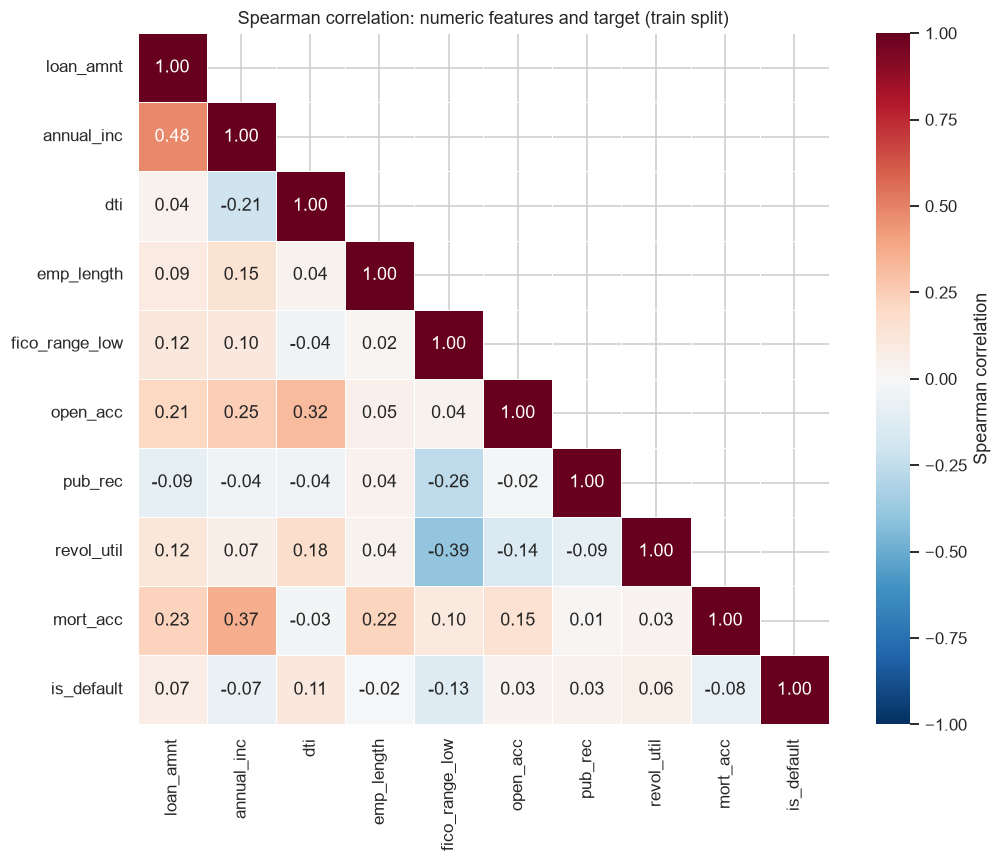

In [14]:
import numpy as np

corr_matrix: pd.DataFrame = df[NUMERIC_FEATURES + [TARGET]].corr(method="spearman")

print("Spearman correlation with the target, sorted by strength:")
print(
    corr_matrix[TARGET]
    .drop(TARGET)
    .sort_values(key=lambda s: s.abs(), ascending=False)
    .to_string()
)

upper_triangle = np.triu(np.ones(corr_matrix.shape, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    mask=upper_triangle,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={"label": "Spearman correlation"},
    ax=ax,
)
ax.set_title("Spearman correlation: numeric features and target (train split)")
plt.tight_layout()
plt.show()

## Step 15: Cramér's V between categorical features and the target

In [15]:
from scipy.stats import chi2_contingency


def cramers_v(x: pd.Series, y: pd.Series) -> float:
    """Cramér's V (without bias correction) between two categorical variables."""
    contingency: pd.DataFrame = pd.crosstab(x, y)
    chi2: float = chi2_contingency(contingency, correction=False)[0]
    n_obs: int = int(contingency.to_numpy().sum())
    min_dim: int = min(contingency.shape) - 1
    return float((chi2 / (n_obs * min_dim)) ** 0.5)


categorical_association: pd.Series = pd.Series(
    {col: cramers_v(df[col], df[TARGET]) for col in CATEGORICAL_FEATURES},
    name="cramers_v_with_target",
).sort_values(ascending=False)
categorical_association.to_frame()

,cramers_v_with_target
term,0.176
verification_status,0.092
home_ownership,0.071
purpose,0.055


### Conclusions: correlations

- **No severe multicollinearity.** The strongest pair among the predictors is `loan_amnt` and `annual_inc` (Spearman 0.48). The next are `revol_util` and `fico_range_low` (-0.39), `annual_inc` and `mort_acc` (0.37), and `dti` and `open_acc` (0.32). All are well below the usual 0.7-0.8 warning level, so no feature has to be dropped for redundancy. The pairs are plausible: larger loans go to higher earners, and high revolving utilization goes with lower FICO scores.
- **Individual numeric features are weak predictors.** Their rank correlation with default is small: `fico_range_low` -0.130, `dti` +0.107, `mort_acc` -0.081, `loan_amnt` +0.071, `annual_inc` -0.067, `revol_util` +0.059, `pub_rec` +0.032, `open_acc` +0.028 and `emp_length` -0.015. All signs are economically sensible: higher FICO score and income, and more mortgage accounts, go with fewer defaults, while higher DTI, utilization, loan size and public records go with more. The maximum is only 0.13, so no feature behaves like a near-perfect proxy for the outcome, and predictive power will have to come from combining features.
- **`emp_length` is weak on its own.** Among borrowers who report it, its rank correlation with default is close to zero (-0.015), whereas the missing group defaults at 26.9%. The missing-indicator flag may therefore carry more information than the value itself.
- **`term` is the strongest single feature.** Its Cramér's V with the target is 0.176 (for a 2x2 table this equals the absolute phi correlation), ahead of `verification_status` (0.092), `home_ownership` (0.071) and `purpose` (0.055). `purpose` has the lowest V despite a wide range of default rates (11.9%-29.4%), because the two categories holding about 80% of loans deviate only moderately from the baseline (21.2% and 16.9%) while the extreme categories are small. Cramér's V and Spearman's rho are not strictly comparable, so this ranking is indicative only.
- **Limit of these measures:** Spearman correlation captures only monotonic relationships, so non-monotonic patterns stay hidden. The next step therefore checks the default rate across quantile bins of each numeric feature.

## Step 16. Binning function and summary table

In [16]:
CAPS: Final[dict[str, int]] = {"pub_rec": 3, "mort_acc": 6}
ORDINAL_FEATURES: Final[set[str]] = {"emp_length", "pub_rec", "mort_acc"}


def default_rate_by_bin(
    frame: pd.DataFrame, col: str, target: str, n_bins: int = 10
) -> pd.DataFrame:
    """Default rate per decile, or per value for ordinal/count features.

    Ordinal and count features use their raw values, with the top value capped
    (see CAPS). Rows where the feature is missing are excluded.
    """
    values: pd.Series = frame[col]
    if col in ORDINAL_FEATURES:
        keys = values.clip(upper=CAPS.get(col))
        result = frame.groupby(keys)[target].agg(n="size", default_rate_pct="mean")
        result["x"] = result.index.to_numpy(dtype=float)
    else:
        keys = pd.qcut(values, q=n_bins, duplicates="drop")
        result = frame.groupby(keys, observed=True)[target].agg(
            n="size", default_rate_pct="mean"
        )
        result["x"] = values.groupby(keys, observed=True).median().to_numpy()
    result["default_rate_pct"] *= 100
    return result.reset_index(drop=True)


bin_profiles: dict[str, pd.DataFrame] = {
    col: default_rate_by_bin(df, col, TARGET) for col in NUMERIC_FEATURES
}

summary_rows: list[dict[str, str | int | float | bool]] = []
for col, profile in bin_profiles.items():
    rate: pd.Series = profile["default_rate_pct"]
    summary_rows.append(
        {
            "feature": col,
            "n_bins": len(profile),
            "first_bin_pct": rate.iloc[0],
            "last_bin_pct": rate.iloc[-1],
            "spread_pp": rate.max() - rate.min(),
            "monotonic": rate.is_monotonic_increasing or rate.is_monotonic_decreasing,
        }
    )

binned_summary: pd.DataFrame = (
    pd.DataFrame(summary_rows)
    .set_index("feature")
    .sort_values("spread_pp", ascending=False)
)
binned_summary

,n_bins,first_bin_pct,last_bin_pct,spread_pp,monotonic
feature,,,,,
fico_range_low,10,26.252,9.224,17.028,True
dti,10,14.644,28.981,14.337,True
mort_acc,7,23.663,14.160,9.503,True
annual_inc,10,24.048,15.157,8.891,True
loan_amnt,10,15.717,24.428,8.712,False
revol_util,10,14.783,22.928,8.145,True
pub_rec,4,19.395,22.973,4.180,False
open_acc,10,18.353,22.389,4.036,False
emp_length,11,20.567,18.766,1.801,False


## Step 17. Default rate by bin, all 9 numeric features

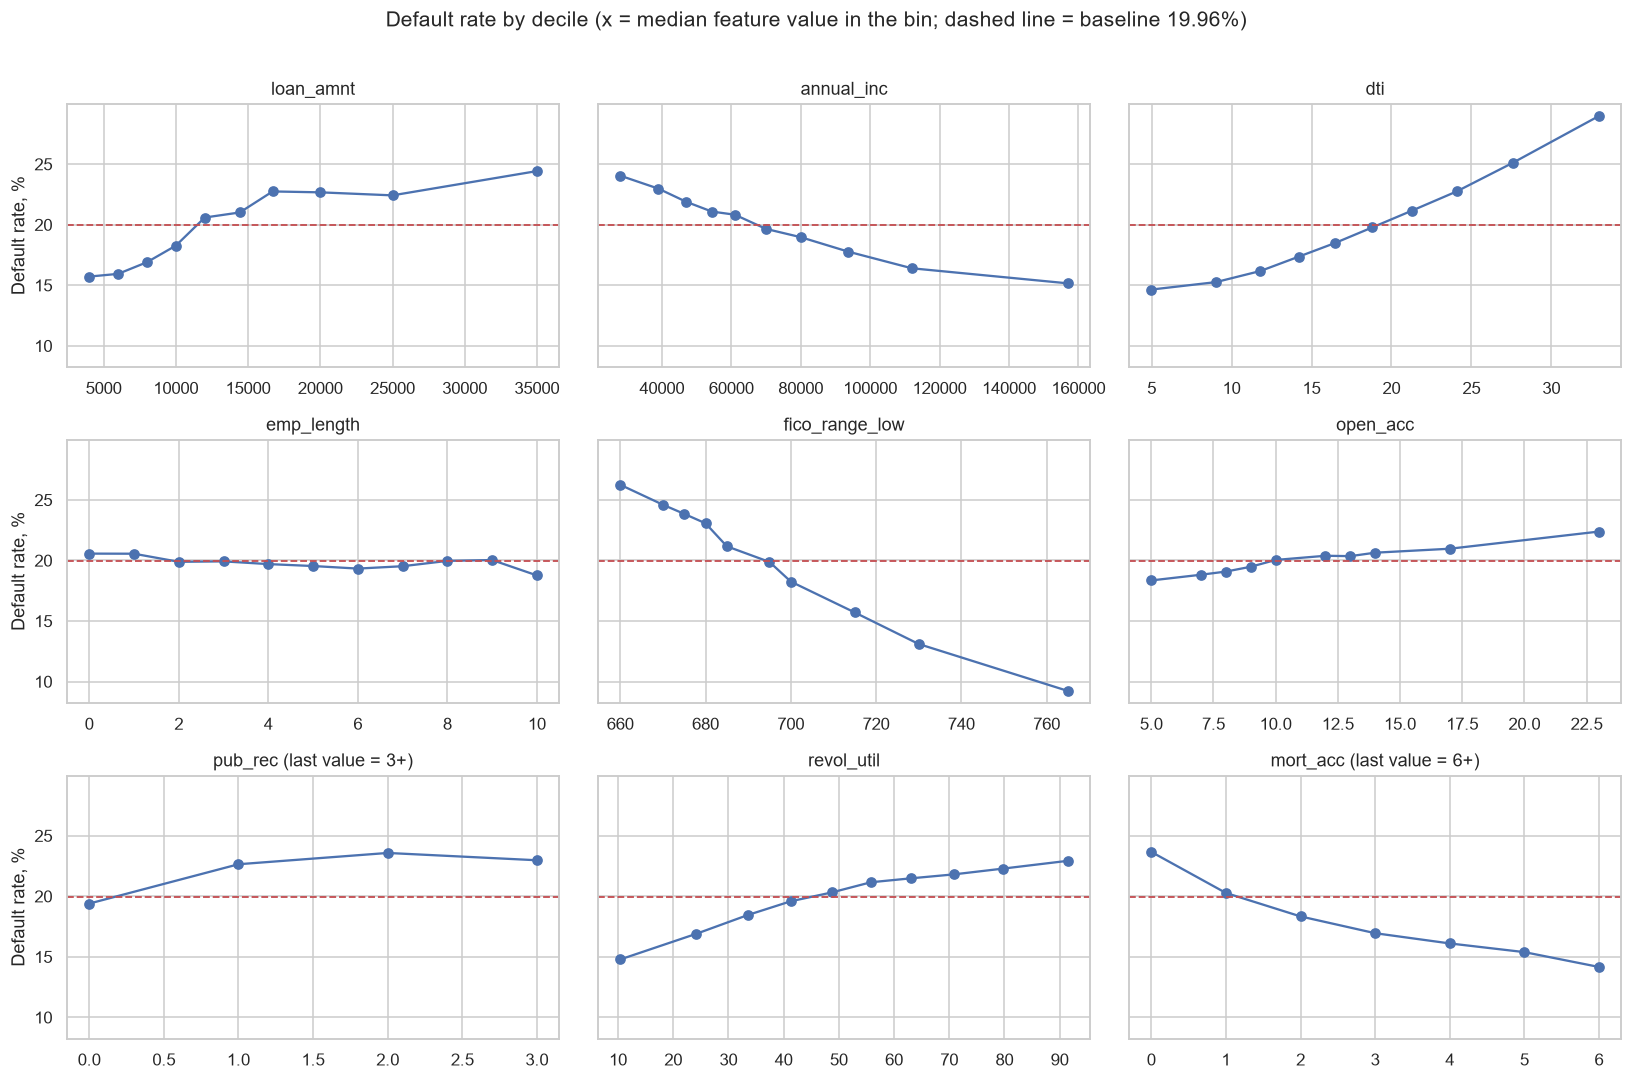

In [17]:
fig, axes = plt.subplots(3, 3, figsize=(15, 10), sharey=True)

for ax, (col, profile) in zip(axes.ravel(), bin_profiles.items()):
    ax.plot(profile["x"], profile["default_rate_pct"], marker="o", color="#4C72B0")
    ax.axhline(baseline_rate, color="#C44E52", linestyle="--", linewidth=1.2)
    ax.set_title(f"{col} (last value = {CAPS[col]}+)" if col in CAPS else col)

for ax in axes[:, 0]:
    ax.set_ylabel("Default rate, %")

fig.suptitle(
    "Default rate by decile (x = median feature value in the bin; "
    f"dashed line = baseline {baseline_rate:.2f}%)",
    fontsize=14,
)
fig.tight_layout(rect=(0, 0, 1, 0.97))
plt.show()

## Summary of EDA findings

All analysis used the training split only (1,076,280 loans; 13 predictors + `is_default`). The test split was not touched.

| Area | Key findings |
| --- | --- |
| Target | 19.96% defaults (861,401 repaid vs 214,879 defaulted, 4.01 : 1). The imbalance is moderate, and accuracy is not a meaningful metric. The target covers only resolved loans (about 40% of raw records, mostly "Current", were excluded), and only accepted applicants are observed. |
| Numeric distributions | Right-skewed with heavy tails: `annual_inc` (skew 44.7, max 9.55M dollars), `dti` (range -1 to 999), `revol_util` (max 892%). `pub_rec` (83% zeros) and `mort_acc` (40% zeros) are zero-inflated counts. `loan_amnt` is capped at 40,000 dollars and clusters at round amounts. `fico_range_low` starts abruptly at 660. |
| Outliers | Upper tail only. Extreme risky values carry signal: `revol_util` > 100 (26.3% default), `dti` > 100 (26.4%) and `pub_rec` >= 3 (23.0%), against a 19.97% baseline. Incomes above 1M dollars default less (11.7%). These are genuine records, not errors. |
| Categorical features | `term` is the strongest (60 months 32.4% vs 36 months 16.0%; Cramér's V 0.176). Renters default more than mortgage holders (23.2% vs 17.2%). `small_business` is the riskiest purpose (29.4%). `verification_status` runs against intuition (Verified 23.9% vs Not Verified 14.7%), most likely because the lender verifies riskier applications. Three levels are rare (fewer than 1,000 loans). |
| Missing values | Only four columns are affected: `emp_length` (5.84%), `mort_acc` (3.53%), `revol_util` (0.07%) and `dti` (0.03%). Missing `emp_length` defaults at 26.9% (vs 19.5%) and missing `mort_acc` at 14.5% (vs 20.2%), so both are informative, in opposite directions. The `dti` and `revol_util` gaps are uninformative. The missingness patterns are independent of each other. |
| Relationship with the target | Rank correlations are weak (at most 0.13 in absolute value), but decile profiles show clear gradients. Spread between the safest and riskiest decile: `fico_range_low` 26.3% to 9.2% (17.0 pp), `dti` 14.6% to 29.0% (14.3 pp), `mort_acc` 9.5 pp, `annual_inc` 8.9 pp, `loan_amnt` 8.7 pp, `revol_util` 8.1 pp. `pub_rec` (4.2 pp) and `open_acc` (4.0 pp) are weak, and `emp_length` (1.8 pp) is nearly flat. |
| Shapes | `fico_range_low`, `dti`, `mort_acc`, `annual_inc` and `revol_util` are monotone. `dti` accelerates in the top deciles, and `annual_inc` and `revol_util` flatten at the high end. `loan_amnt` rises to about 17k dollars, plateaus at 22-23% up to 25k dollars, then reaches 24.4% in the top decile. `pub_rec` matters mainly as 0 versus 1 or more. |
| Redundancy | No severe multicollinearity. The highest correlation among predictors is 0.48 (`loan_amnt` and `annual_inc`). |

**Univariate signal ranking:** strong: `fico_range_low`, `dti`, `term`. Moderate: `mort_acc`, `annual_inc`, `loan_amnt`, `revol_util`, `verification_status`. Weak: `pub_rec`, `open_acc`, `home_ownership`, `purpose`. `emp_length` matters mainly through its missing-value flag.

## Preprocessing decisions for the modelling stage

These are candidates to implement in `src/ml_model/` and to validate with held-out metrics. Every statistic is fitted on the training split only, inside a scikit-learn `Pipeline` / `ColumnTransformer`.

| Topic | Decision | Evidence |
|---|---|---|
| Split and leakage | Keep the stratified 80/20 split (`random_state=42`). Fit every imputer, clipper, encoder and scaler on the training split only. `int_rate` and `installment` stay excluded. | The split preserved the class balance (19.965%). No feature is a near-perfect proxy for the target (maximum rank correlation 0.13). |
| Missing values | `emp_length` and `mort_acc`: median imputation plus a missing-indicator flag (`SimpleImputer(strategy="median", add_indicator=True)` on these two columns). `dti` and `revol_util`: plain median imputation. | Missingness of `emp_length` and `mort_acc` is informative (26.9% and 14.5% default vs about 20%). For `dti` and `revol_util` it is uninformative and affects under 0.1% of rows. |
| Outliers | Remove no rows. Winsorize numeric features at percentiles fitted on the training split (starting point: 0.1th and 99.9th), using a small custom transformer. | Extreme values are genuine and often carry signal (`revol_util` > 100, `dti` > 100, `pub_rec` >= 3), so they are clipped rather than deleted. |
| Transformations | `annual_inc`: `log1p` for linear models. `pub_rec` and `mort_acc`: add binary indicators (`> 0`) next to the capped counts. `emp_length`: keep numeric plus the missing flag, and test dropping the value. `loan_amnt`, `dti`, `revol_util`: rely on trees, or on binning in a linear baseline, for their non-linear shapes. | Skew of 44.7 and a convex income profile. `pub_rec` matters mainly as 0 vs 1 or more. `emp_length` spread is only 1.8 pp. `loan_amnt` plateaus above about $17k, and `dti` accelerates in the top deciles. |
| Scaling | `RobustScaler` (or `StandardScaler` after clipping) for linear models. None is needed for the Random Forest. | Heavy tails distort mean and standard-deviation scaling. |
| Categorical encoding | One-hot encoding with `handle_unknown="infrequent_if_exist"` and a small `min_frequency` (for example 0.001) so rare levels are pooled. `term` stays binary. | Low cardinality (2, 3, 4 and 14 levels). A 0.1% threshold is about 1,076 loans, and only three levels fall below it: `educational` (269), `home_ownership = OTHER` (382) and `renewable_energy` (729). |
| Class imbalance | No resampling. Use `class_weight` (balanced or tuned), tune the decision threshold, and use stratified cross-validation. Evaluate with ROC AUC, PR AUC, KS, and precision and recall at the chosen threshold. | Ratio of 4.01 : 1 with 214,879 positives. Accuracy is uninformative (80.04% for "always non-default"). |
| Feature set | Keep all 13 features for now and re-check `emp_length`, `open_acc` and `purpose` with permutation importance. Interpret `verification_status` as a proxy for the lender's screening. | No redundancy (maximum 0.48). Those three features show weak univariate signal. |
| Service contract | Make `emp_length` and `mort_acc` optional (nullable) in the request schema. Restrict `term` to the two trained values (`"36 months"`, `"60 months"`) and rely on `handle_unknown` for unseen categories. | Missingness carries signal, and the training data contains only those two term values. |

**Limitations to state in the thesis:**

1. Only accepted applicants are observed, so there is selection bias and no reject inference.
2. Only resolved loans are used, so recent 60-month loans that are still being repaid are excluded (censoring).
3. The training file has no origination date, so out-of-time validation and vintage effects (for example the `mort_acc` gaps) cannot be tested. Adding the origination date (`issue_d` in the raw LendingClub file) for splitting and diagnostics, not as a feature, would remove this limit.